In [100]:
import os
import cv2
import dlib
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

from scipy.spatial.distance import cdist
from google.colab import files
from google.colab.patches import cv2_imshow

#!unzip -q "dataset.zip" -d .

In [101]:
def Hog_extract(img, resize_to=(128,128)):
    if img is None:
        return None

    # Convert to gray
    if len(img.shape) == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.resize(gray, resize_to)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return features.astype("float32")

In [102]:
def load_dataset(dataset="dataset", resize=(128,128), valid_ext=(".jpg",".jpeg",".png",".pgm")):

    detector = dlib.get_frontal_face_detector()

    X, y = [], []
    label_map = {}
    label_id = 0

    for person in sorted(os.listdir(dataset)):
        folder = os.path.join(dataset, person)
        if not os.path.isdir(folder):
            continue

       # print("Loading:", person)
        label_map[label_id] = person

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            if not img_path.lower().endswith(valid_ext):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if img is None:
                continue

            gray = img if len(img.shape) == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            faces, scores, idx = detector.run(gray, 1)

            if len(faces) == 0:
                face = img
            else:
                d = faces[0]
                score = scores[0]
                norm_score = max(0.2, min(score / 10.0, 1.0))
                adap_f = 0.35 * (1.0 / norm_score)

                x, y0, w, h = d.left(), d.top(), d.width(), d.height()
                pad = int(0.35 * d.width())


                x1, y1 = max(0, x - pad), max(0, y0 - pad)
                x2 = min(img.shape[1], x + w + pad)
                y2 = min(img.shape[0], y0 + h + pad)

                face = img[y1:y2, x1:x2]

            feat = Hog_extract(face, resize_to=resize)
            if feat is not None:
                X.append(feat)
                y.append(label_id)

        label_id += 1

    return np.array(X), np.array(y), label_map


In [103]:
def clean_images(folder_paths, min_std=8):

    removed = []
    for p in folder_paths:
        img = cv2.imread(p)
        if img is None:
            try:
                os.remove(p)
            except:
                pass
            removed.append(p)
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        if gray.std() < min_std:
            try:
                os.remove(p)
            except:
                pass
            removed.append(p)
    print(f"Removed {len(removed)} low-std images.")
    return removed

In [104]:
X, y, label_map = load_dataset("dataset", resize=(128,128))
print("Loaded:", X.shape)

norms = np.linalg.norm(X, axis=1)
out_idx = np.where(norms < np.percentile(norms, 2))[0]
print("Outliers detected (low-norm):", len(out_idx))
if len(out_idx) > 0:
    X = np.delete(X, out_idx, axis=0)
    y = np.delete(y, out_idx, axis=0)
print("After low-norm removal:", X.shape)

Loaded: (400, 8100)
Outliers detected (low-norm): 2
After low-norm removal: (398, 8100)


In [105]:
classes = np.unique(y)
class_means = np.array([X[y == cls].mean(axis=0) for cls in classes])
between_var = np.var(class_means, axis=0)
eps = 1e-8
weights = (between_var + eps) / (np.mean(between_var) + eps)
#X = X * weights


In [106]:
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.20, random_state=42, stratify=y_train_all
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (254, 8100) Val: (64, 8100) Test: (80, 8100)


In [107]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("norm", Normalizer(norm="l2")),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])
knn.fit(X_train, y_train)
knn_test = knn.predict(X_test)
print(classification_report(y_test, knn_test,
                            target_names=[label_map[i] for i in sorted(label_map.keys())],
                            zero_division=0))


              precision    recall  f1-score   support

          s1       0.67      1.00      0.80         2
         s10       1.00      0.50      0.67         2
         s11       1.00      1.00      1.00         2
         s12       1.00      1.00      1.00         2
         s13       0.50      0.50      0.50         2
         s14       1.00      1.00      1.00         2
         s15       1.00      1.00      1.00         2
         s16       0.50      0.50      0.50         2
         s17       1.00      1.00      1.00         2
         s18       0.50      0.50      0.50         2
         s19       1.00      1.00      1.00         2
          s2       1.00      1.00      1.00         2
         s20       1.00      1.00      1.00         2
         s21       0.67      1.00      0.80         2
         s22       1.00      1.00      1.00         2
         s23       0.40      1.00      0.57         2
         s24       0.67      1.00      0.80         2
         s25       1.00    

In [108]:
val_probs = knn.predict_proba(X_val)
y_val_bin = label_binarize(y_val, classes=sorted(label_map.keys()))

op_threshold = {}
for i, cls in enumerate(sorted(label_map.keys())):
    try:
        fpr, tpr, thr = roc_curve(y_val_bin[:, i], val_probs[:, i])
        j = tpr - fpr
        idx = np.argmax(j)
        op_threshold[cls] = thr[idx]
    except Exception as e:
        op_threshold[cls] = 0.1  # fallback
        print(f"Threshold {cls}: {e}")

for c in op_threshold:
    print(label_map[c], "->", round(op_threshold[c], 4))

s1 -> 0.3333
s10 -> 0.6667
s11 -> 0.3333
s12 -> 0.6667
s13 -> 0.6667
s14 -> 1.0
s15 -> 0.6667
s16 -> 1.0
s17 -> 0.6667
s18 -> 0.3333
s19 -> 1.0
s2 -> 0.6667
s20 -> 0.3333
s21 -> 0.6667
s22 -> 1.0
s23 -> 0.3333
s24 -> 1.0
s25 -> 0.3333
s26 -> 1.0
s27 -> 1.0
s28 -> 0.3333
s29 -> 0.3333
s3 -> 0.3333
s30 -> inf
s31 -> 0.3333
s32 -> 0.6667
s33 -> 0.6667
s34 -> 1.0
s35 -> 1.0
s36 -> 1.0
s37 -> 0.6667
s38 -> 0.6667
s39 -> 0.3333
s4 -> 0.3333
s40 -> 0.3333
s5 -> 0.6667
s6 -> 0.3333
s7 -> 1.0
s8 -> 1.0
s9 -> 0.6667


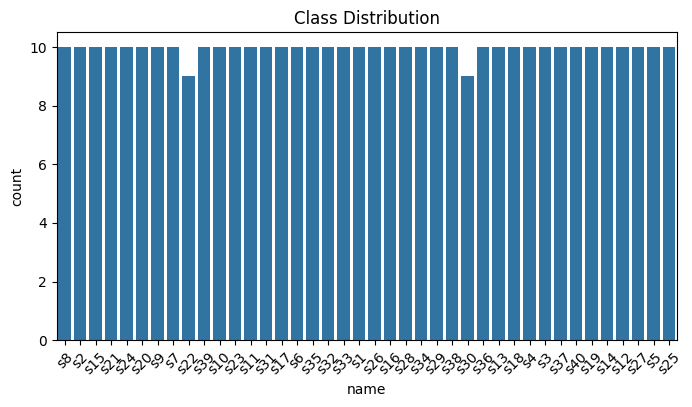

In [109]:
df = pd.DataFrame({"label": np.concatenate([y_train, y_val, y_test])})
df["name"] = df["label"].map(label_map)
plt.figure(figsize=(8,4))
sns.countplot(x=df["name"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

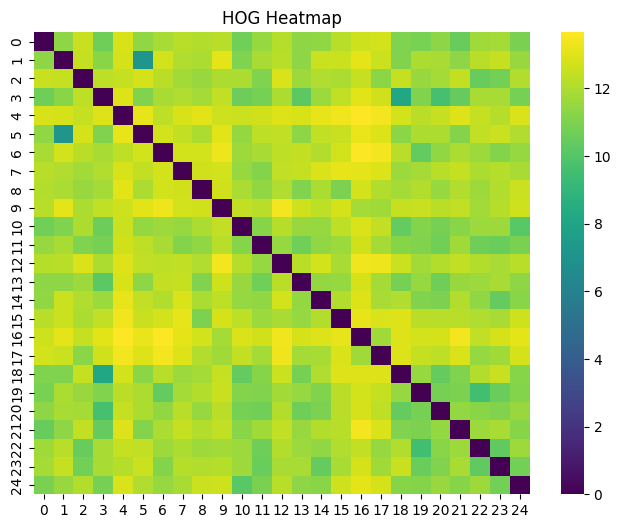

In [110]:
idx = np.random.choice(len(X), min(25, len(X)), replace=False)
mat = cdist(X[idx], X[idx])
plt.figure(figsize=(8,6))
sns.heatmap(mat, cmap="viridis")
plt.title("HOG Heatmap")
plt.show()

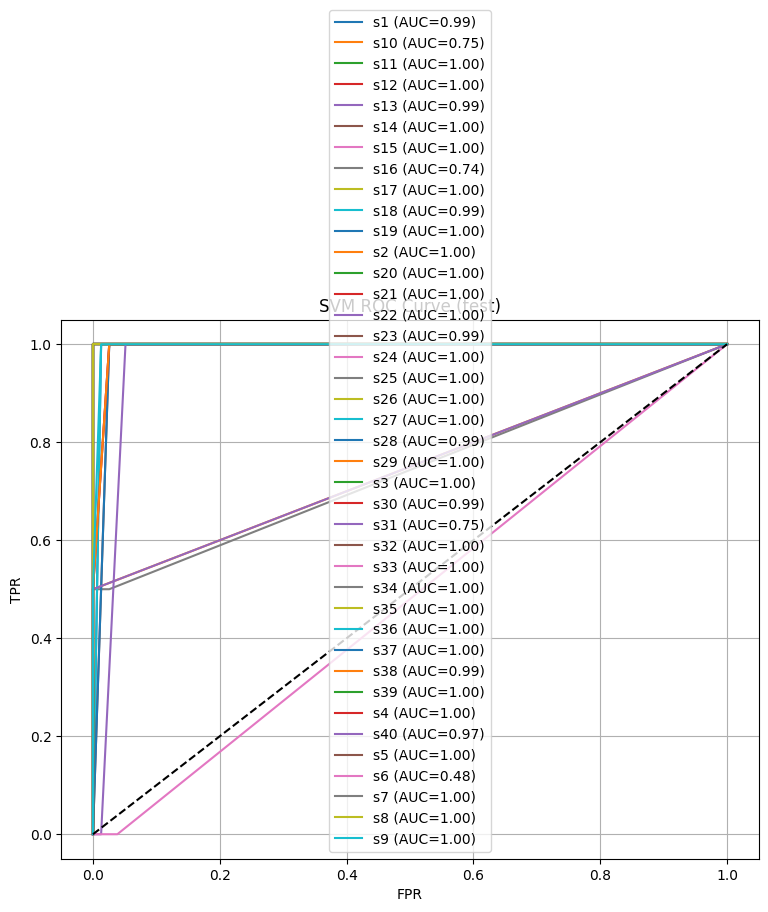

In [111]:
plt.figure(figsize=(9,7))
KNN_prob = knn.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=sorted(label_map.keys()))
for i, cls in enumerate(sorted(label_map.keys())):
    try:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], KNN_prob[:, i])
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_map[cls]} (AUC={auc_val:.2f})")
    except:
        pass
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("SVM ROC Curve (test)")
plt.grid()
plt.show()

In [ ]:
def predict_image():
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    img = cv2.imread(img_path)
    if img is None:
        print("Error loading image")
        return

    detector = dlib.get_frontal_face_detector()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces, scores, _ = detector.run(gray, 1)

    if len(faces) == 0:
        print("No face detected")
        cv2_imshow(img)
        return

    d = faces[0]
    score = scores[0] if len(scores) > 0 else 1.0
    norm_score = max(0.2, min(score / 10.0, 1.0))
    adap_f = 0.35 * (1.0 / norm_score)
    pad = int(0.35 * d.width())

    x1 = max(0, d.left() - pad)
    y1 = max(0, d.top() - pad)
    x2 = min(img.shape[1], d.right() + pad)
    y2 = min(img.shape[0], d.bottom() + pad)

    face = img[y1:y2, x1:x2]
    hog_vec = Hog_extract(face, resize_to=(128,128))

    prob = knn.predict_proba([hog_vec])[0]
    best = np.argmax(prob)
    thr = min(op_threshold.get(best, 0.1), 0.40)

    safe_thr = min(thr, 0.30)

    if prob[best] < safe_thr:
        label = "Unknown"
        msg = f"Unknown (prob={prob[best]:.3f} < thr={thr:.3f})"
    else:
        label = label_map[best]
        msg = f"{label} ({prob[best]:.3f})"

    print("Prediction:", msg)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
    cv2.putText(img, msg, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
    cv2_imshow(img)
predict_image()

In [113]:

joblib.dump(knn, "knn_pipeline.joblib")
joblib.dump(op_threshold, "hog_svm_thresholds.joblib")
np.save("hog_label_map.npy", label_map)

